## Imports and paths

In [28]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import FlatLambdaCDM

from pyLensLib.compositeModel import compositeModel
from pyLensLib.nfwell import nfwell
from pyLensLib.sersic import sersic
from pyLensLib.sie import sie

%matplotlib inline

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

outdir = project_root / "outputs"
outdir.mkdir(exist_ok=True)

outdir

PosixPath('/home/sabrina-n/tesi-triennale/outputs')

## Cosmology and image grid

In [2]:
co = FlatLambdaCDM(H0=70.0, Om0=0.3)
zl = 0.5 # 0.5, 0.2 
zs = 2.0 # 0.5: 2 o 1.5 , 0.2: 1

fov = 6.0 # field of view, quanto è grande l'immagine, il plot, in arcsec 
npix = 220 # numero di pixel 
theta = np.linspace(-fov / 2.0, fov / 2.0, npix)
extent = [-fov / 2.0, fov / 2.0, -fov / 2.0, fov / 2.0]
focused_extent = [-fov / 12.0, fov / 12.0, -fov / 12.0, fov / 12.0]

print(f"Grid: {npix} x {npix} pixels over {fov:.1f} arcsec")
print(f"Lens redshift: {zl:.2f}; source redshift: {zs:.2f}")

Grid: 220 x 220 pixels over 6.0 arcsec
Lens redshift: 0.50; source redshift: 2.00


# Variazione di Sigma0

## Define the SIE lens, define and lens the source, add lens-galaxy light
 

In [3]:
sigma0_values = [180, 250, 290]
total_images = []
kappa_maps = []
critical_lines_all = []
einstein_radii =np.zeros(len(sigma0_values))

for i, sigma0 in enumerate(sigma0_values):
 lens = sie(
     co,
     zl=zl, # redshift lente
     zs=zs, # redshift sorgente, più alto della lente 
     sigma0=sigma0,
     q=0.75, # ellipticity
     pa=np.deg2rad(35.0), # angular position of the major ax
     theta_c=1.0e-4, # core radius, if 0 the profile becomes singular
     x1=0.0,
     x2=0.0,
 )
 lens.setGrid(theta=theta)
 
 critical_lines = [lens.getCritPoints(cl) for cl in lens.tancl()]
 einstein_radii[i] = lens.bsie()

 source_kwargs = {
    "n": 1.0,
    "re": 0.15,
    "q": 0.7,
    "pa": np.deg2rad(20.0),
    "ys1": 0.06, # posizione sorgente, DA MODIFICARE
    "ys2": 0.03, # posizione sorgente, DA MODIFICARE, 2-3 CASI 
    "flux": 1.0e4,
    "zs": zs,
}

 source = sersic(size=fov, Npix=npix, gl=lens, save_unlensed=True, **source_kwargs) # Lensing of a Sersic source

 lens_light_kwargs = {
    "n": 4.0,
    "re": 0.55,
    "q": 0.8,
    "pa": np.deg2rad(35.0),
    "ys1": 0.0,
    "ys2": 0.0,
    "flux": 3.0e4,
    "zs": zl,
 }

 lens_light = sersic(size=fov, Npix=npix, gl=None, **lens_light_kwargs) # adds the light of the lens galaxy, using a second Sersic profile 
 total_image = source.image + lens_light.image

 total_images.append(total_image.copy())
 kappa_maps.append(lens.ka)
 critical_lines_all.append(critical_lines)

## Visualize the lensing configuration

Raggio di Einstein per sigma_0=180: 0.6855653958582628 arcsec
Raggio di Einstein per sigma_0=250: 1.322464112380908 arcsec
Raggio di Einstein per sigma_0=290: 1.77950770961975 arcsec


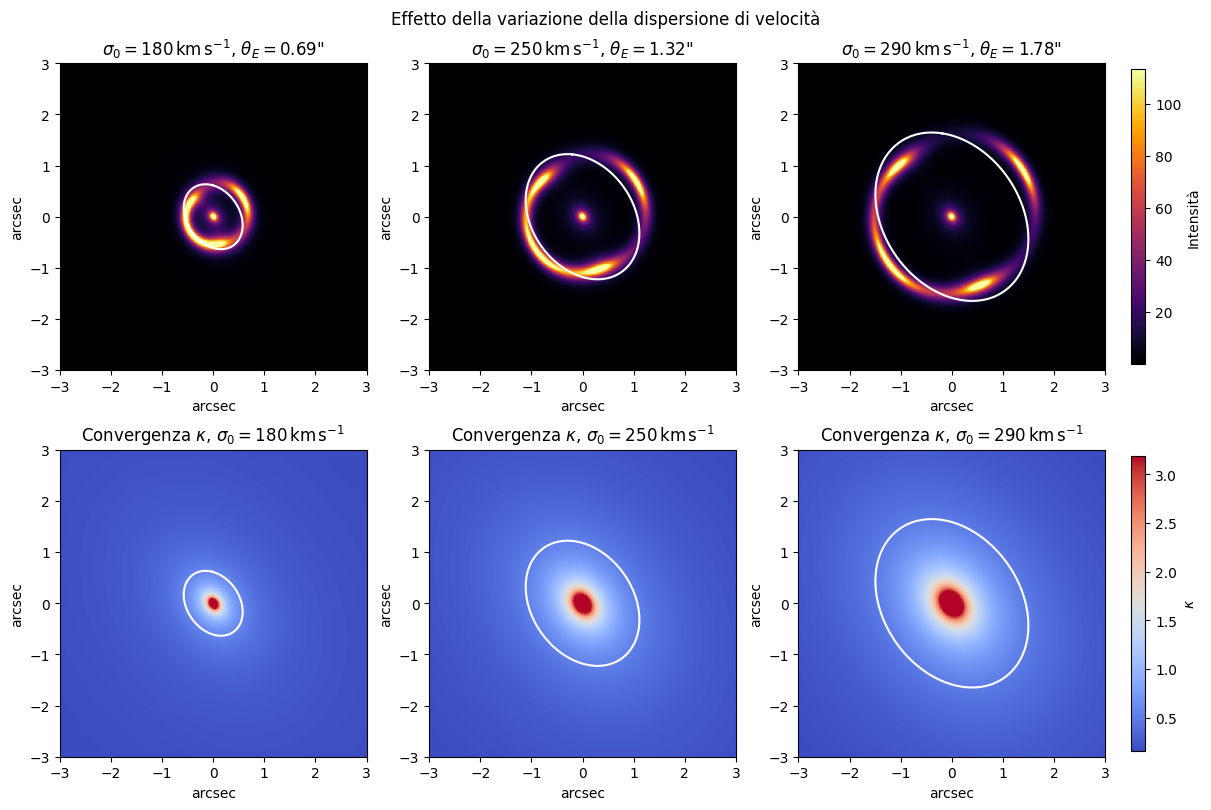

In [4]:
fig1, ax1 = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
fig1.suptitle("Effetto della variazione della dispersione di velocità")

vmax_image = max(
np.percentile(img[np.isfinite(img)], 99.5)
for img in total_images
)

vmax_kappa = max(
np.percentile(k[np.isfinite(k)], 99.5)
for k in kappa_maps
)

for i, sigma0 in enumerate(sigma0_values):
    im0 = ax1[0,i].imshow(total_images[i], origin="lower", extent=extent, cmap="inferno", vmax=vmax_image)
    ax1[0,i].set_xlabel("arcsec")
    ax1[0,i].set_ylabel("arcsec")

    im1 = ax1[1,i].imshow(kappa_maps[i], origin="lower", extent=extent, cmap="coolwarm", vmax=vmax_kappa)
    ax1[1,i].set_xlabel("arcsec")
    ax1[1,i].set_ylabel("arcsec")

    ax1[0,i].set_title(
    rf'$\sigma_0={sigma0}\,\mathrm{{km\,s^{{-1}}}}$, '
    rf'$\theta_E={einstein_radii[i]:.2f}$"')
    ax1[1,i].set_title(
    rf'Convergenza $\kappa$, $\sigma_0={sigma0}\,\mathrm{{km\,s^{{-1}}}}$')
    print(f"Raggio di Einstein per sigma_0={sigma0}: {einstein_radii[i]} arcsec")
    
for i in range(len(sigma0_values)):
    for xcrit, ycrit in critical_lines_all[i]:
        ax1[0,i].plot(xcrit, ycrit, color="white")
        ax1[1,i].plot(xcrit, ycrit, color="white")

for ax in ax1.flat:
    ax.set_aspect("equal")

cbar0 = fig1.colorbar(
    im0,
    ax=ax1[0, :],
    shrink=0.85,
    pad=0.02
)
cbar0.set_label("Intensità")

cbar1 = fig1.colorbar(
    im1,
    ax=ax1[1, :],
    shrink=0.85,
    pad=0.02
)
cbar1.set_label(r"$\kappa$")


## Salvataggio

In [5]:
figure_path = outdir / "final_simulations_sigma0.png"
fig1.savefig(figure_path, dpi=180)
print(f"Saved {figure_path}")

Saved /home/sabrina-n/tesi-triennale/outputs/final_simulations_sigma0.png


# Disallineamento


## Define the SIE lens, define and lens the source, add lens-galaxy light
 

In [6]:
positions = ((0.01, 0.03), (0.15, 0.1), (-0.15,0.05), (0.3, 0.3))
total_images_2 = []
unlensed_images = []
critical_lines_all_2 = []
caustics_all =[]
einstein_radii_2 =np.zeros(len(positions))

for i, position in enumerate(positions):
 lens2 = sie(
     co,
     zl=zl, # redshift lente
     zs=zs, # redshift sorgente, più alto della lente 
     sigma0=220.0,
     q=0.75, # ellipticity
     pa=np.deg2rad(35.0), # angular position of the major ax
     theta_c=1.0e-4, # core radius, if 0 the profile becomes singular
     x1=0.0,
     x2=0.0,
 )
 lens2.setGrid(theta=theta)
 
 critical_lines2 = [lens2.getCritPoints(cl) for cl in lens2.tancl()]
 einstein_radii_2[i] = lens2.bsie()

 source_kwargs2 = {
    "n": 1.0,
    "re": 0.15,
    "q": 0.7,
    "pa": np.deg2rad(20.0),
    "ys1": position[0], # posizione sorgente, DA MODIFICARE
    "ys2": position[1], # posizione sorgente, DA MODIFICARE, 2-3 CASI 
    "flux": 1.0e4,
    "zs": zs,
}

 source2 = sersic(size=fov, Npix=npix, gl=lens2, save_unlensed=True, **source_kwargs2) # Lensing of a Sersic source
 unlensed_images.append(source2.image_unlensed)
 caustics = lens2.getCaustics(lens2.tancl())

 lens_light_kwargs2 = {
    "n": 4.0,
    "re": 0.55,
    "q": 0.8,
    "pa": np.deg2rad(35.0),
    "ys1": 0.0,
    "ys2": 0.0,
    "flux": 3.0e4,
    "zs": zl,
 }

 lens_light2 = sersic(size=fov, Npix=npix, gl=None, **lens_light_kwargs2) # adds the light of the lens galaxy, using a second Sersic profile 
#  total_image = source.image + lens_light.image
 source_image = source2.image

 total_images_2.append(source_image.copy())

 critical_lines_all_2.append(critical_lines2)
 caustics_all.append(caustics)


## Visualize the lensing configuration

Raggio di Einstein per position=(0.01, 0.03): 1.0241162086277753 arcsec
Raggio di Einstein per position=(0.15, 0.1): 1.0241162086277753 arcsec
Raggio di Einstein per position=(-0.15, 0.05): 1.0241162086277753 arcsec
Raggio di Einstein per position=(0.3, 0.3): 1.0241162086277753 arcsec


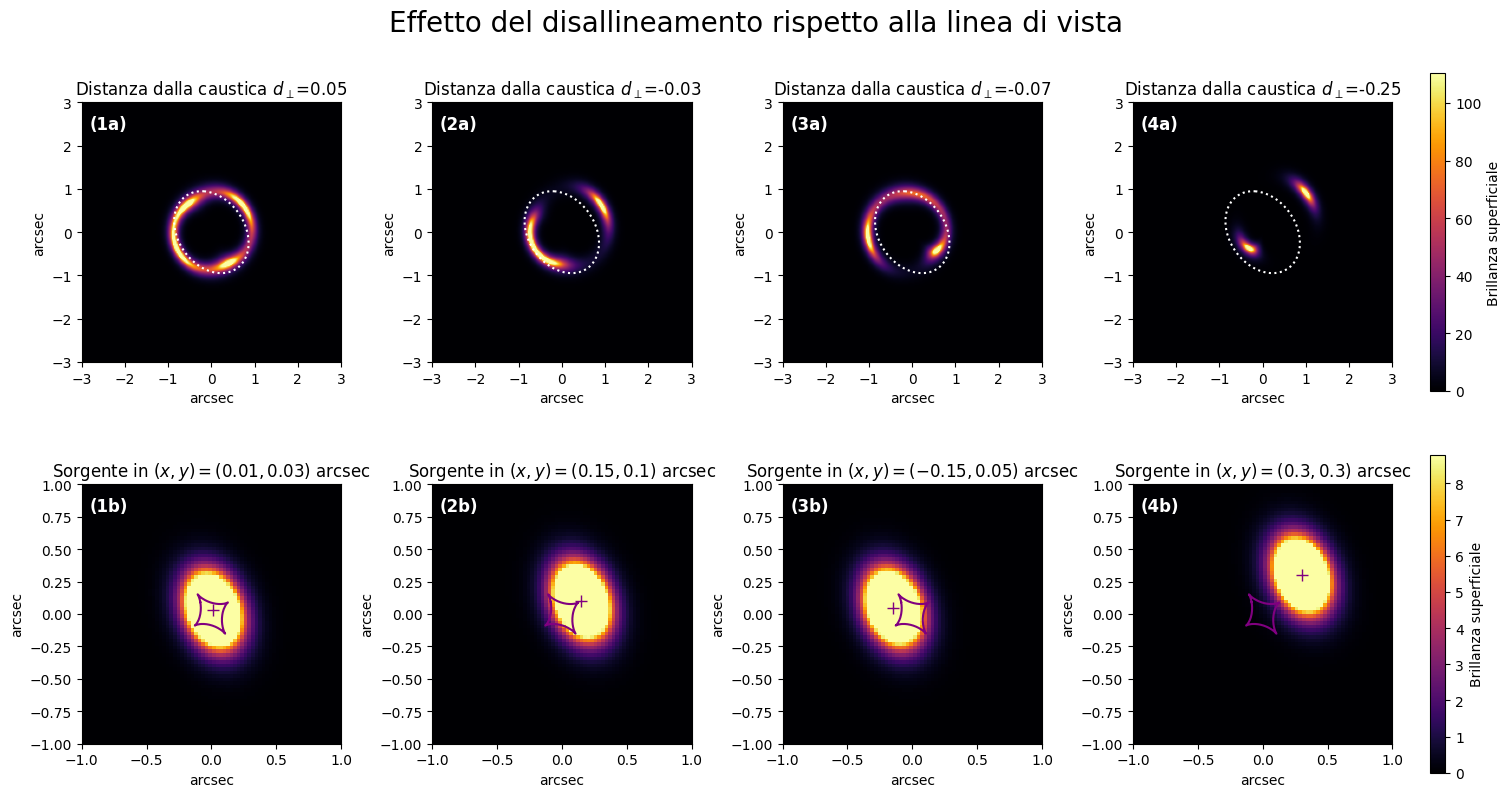

In [7]:
d_caustic_all = []

fig2, ax2 = plt.subplots(2, 4, figsize=(15, 8), constrained_layout=True)
fig2.suptitle("Effetto del disallineamento rispetto alla linea di vista", fontsize = 20)

vmax_image2 = max(
    np.percentile(img[np.isfinite(img)], 99.5)
    for img in total_images_2
)

vmax_unlensed = max(
    np.percentile(u[np.isfinite(u)], 99.5)
    for u in unlensed_images
)

for i in range(len(positions)):
    for xcrit, ycrit in critical_lines_all_2[i]:
            ax2[0,i].plot(xcrit, ycrit, color="white", linestyle= "dotted")
    
    position = np.array(positions[i])
    distances = []

    for cau in caustics_all[i]:
        xcau, ycau = lens2.getCausticPoints(cau)
        # Disegna la caustica
        ax2[1, i].plot(xcau, ycau, color="purple")
        # Coordinate dei punti della caustica
        caustic_points = np.column_stack((xcau, ycau))
        # Distanza della sorgente da ogni punto della caustica
        dists = np.linalg.norm(caustic_points - position, axis=1)
        # Punto della caustica più vicino alla sorgente
        j = np.argmin(dists)
        x0 = xcau[j]
        y0 = ycau[j]
        # Tangente locale alla caustica
        dx = np.gradient(xcau)
        dy = np.gradient(ycau)
        tangent = np.array([dx[j], dy[j]])
        # Normalizzazione della tangente
        tangent /= np.linalg.norm(tangent)
        # Normale alla caustica
        normal = np.array([-tangent[1], tangent[0]])
        # Vettore dal punto della caustica alla sorgente
        delta = position - np.array([x0, y0])
        # Distanza firmata lungo la normale
        d_normal = np.dot(delta, normal)
        distances.append(d_normal)
    # Distanza normale dalla caustica più vicina
    d_caustic = min(distances, key=abs)
    d_caustic_all.append(d_caustic)

for i, position in enumerate(positions):
    im0 = ax2[0,i].imshow(total_images_2[i], origin="lower", extent=extent, cmap="inferno", vmax=vmax_image2)
    ax2[0,i].set_xlabel("arcsec")
    ax2[0,i].set_ylabel("arcsec")

    im1 = ax2[1,i].imshow(unlensed_images[i], origin="lower", extent=extent, cmap="inferno", vmax=vmax_unlensed)
    ax2[1,i].set_xlim(-1, 1)
    ax2[1,i].set_xlabel("arcsec")
    ax2[1,i].set_ylim(-1, 1)
    ax2[1,i].set_ylabel("arcsec")
    


    ax2[0,i].set_title(f'Distanza dalla caustica $d_\perp$={d_caustic_all[i]:.2f}')
    ax2[1,i].set_title(
    rf'Sorgente in $(x,y)={position}$ arcsec')
    ax2[1,i].plot(
    position[0],
    position[1],
    marker='+',
    color='purple',
    markersize=8
)

    print(f"Raggio di Einstein per position={position}: {einstein_radii_2[i]} arcsec")


for ax in ax2.flat:
    ax.set_aspect("equal")

cbar0 = fig2.colorbar(
    im0,
    ax=ax2[0, :],
    shrink=0.85,
    pad=0.02
)
cbar0.set_label("Brillanza superficiale")

cbar1 = fig2.colorbar(
    im1,
    ax=ax2[1, :],
    shrink=0.85,
    pad=0.02
)
cbar1.set_label("Brillanza superficiale")

labels_a = ["(1a)", "(2a)", "(3a)", "(4a)"]
labels_b = ["(1b)", "(2b)", "(3b)", "(4b)"]

for i, lab in enumerate(labels_a):
    ax2[0,i].text(
        0.03, 0.95,
        lab,
        transform=ax2[0,i].transAxes,
        color="white",
        fontsize=12,
        fontweight="bold",
        va="top"
    )

for i, lab in enumerate(labels_b):
    ax2[1,i].text(
        0.03, 0.95,
        lab,
        transform=ax2[1,i].transAxes,
        color="white",
        fontsize=12,
        fontweight="bold",
        va="top"
    )


## Salvataggio

In [8]:
figure_path2 = outdir / "final_simulations_positions.png"
fig2.savefig(figure_path2, dpi=180)
print(f"Saved {figure_path2}")

Saved /home/sabrina-n/tesi-triennale/outputs/final_simulations_positions.png


## Test 1

In [9]:
print("max total_images_2 (no lens)=", np.max([np.nanmax(img) for img in total_images_2]))
print("max unlensed_images =", np.max([np.nanmax(img) for img in unlensed_images]))

print("lensed: ", np.max(source.image))
print("unlensed: ", np.max(source.image_unlensed))

print("source image: ", np.nanmax(source.image))
print("lens image: ", np.nanmax(lens_light.image))
print("total image: ", np.nanmax(total_image))


max total_images_2 (no lens)= 205.80200503299602
max unlensed_images = 200.5859721221491
lensed:  197.7239232824507
unlensed:  171.35661857788332
source image:  197.7239232824507
lens image:  309.44717226450143
total image:  309.44718044375446


## Test 2

In [10]:
for i in range(len(total_images_2)):
    print(
        "lensed",
        np.max(total_images_2[i]),
        np.percentile(total_images_2[i], 99.5)
    )

    print(
        "unlensed",
        np.max(unlensed_images[i]),
        np.percentile(unlensed_images[i], 99.5)
    )

lensed 205.58716288678653 110.27507382645216
unlensed 180.28878765848054 8.38219861508474
lensed 205.80200503299602 90.09219312534897
unlensed 200.5859721221491 8.613026859854596
lensed 195.1329413180307 70.16000977881441
unlensed 188.8059121327078 8.39742434043863
lensed 187.05552388364694 43.2811554373767
unlensed 167.3762530939433 8.78014661659729


# Perturbatore SIE 

## Define the SIE lens, define and lens the source, add lens-galaxy light
 

In [11]:
lens3 = sie(
    co,
    zl=zl, # redshift lente
    zs=zs, # redshift sorgente, più alto della lente 
    sigma0=260.0,
    q=0.75, # ellipticity
    pa=np.deg2rad(35.0), # angular position of the major ax
    theta_c=1.0e-4, # core radius, if 0 the profile becomes singular
    x1=0.0,
    x2=0.0,
 )
lens3.setGrid(theta=theta)
 
critical_lines3 = [lens3.getCritPoints(cl) for cl in lens3.tancl()]

source_kwargs3 = {
   "n": 1.0,
   "re": 0.15,
   "q": 0.7,
   "pa": np.deg2rad(20.0),
   "ys1": 0.06, 
   "ys2": 0.03, 
   "flux": 1.0e4,
   "zs": zs,
}

source3 = sersic(size=fov, Npix=npix, gl=lens3, save_unlensed=True, **source_kwargs3) # Lensing of a Sersic source

lens_light_kwargs3 = {
    "n": 4.0,
    "re": 0.55,
    "q": 0.8,
    "pa": np.deg2rad(35.0),
    "ys1": 0.0,
    "ys2": 0.0,
    "flux": 3.0e4,
    "zs": zl,
 }

lens_light3 = sersic(size=fov, Npix=npix, gl=None, **lens_light_kwargs3) # adds the light of the lens galaxy, using a second Sersic profile 
total_image3 = source3.image + lens_light3.image

## Add a second SIE mass component

In [12]:
second_lens_kind = "SIE" 
second_lens_enabled = True

pert_pos = [-1.3, 0.1]
sigma0_values_pert = [50.0, 70.0, 90.0]
second_lens_all = []
composite_lens_all = []
composite_critical_lines = []

for sigma0_pert in sigma0_values_pert:
    second_sie_kwargs = {
    "sigma0": sigma0_pert, # cambiando qui diminuire, max 90
    "q": 0.9,
    "pa": np.deg2rad(-20.0),
    "theta_c": 1.0e-4,
    "x1": pert_pos[0], # 0.8, 1
    "x2": pert_pos[1], # 1, -1
}

    second_nfw_kwargs = {
    "mass": 5.0e11, # cambiando qui diminuire, max 5.0e11
    "conc": 11.0,
    "q": 0.95,
    "pa": np.deg2rad(-20.0),
    "x1": pert_pos[0],
    "x2": pert_pos[1],
}

    def build_second_lens(kind, enabled=True):
        if not enabled:
         return None

        kind = kind.upper()
        if kind == "SIE":
         return sie(co, zl=zl, zs=zs, **second_sie_kwargs)
        if kind == "NFW":
         return nfwell(co, zl=zl, zs=zs, **second_nfw_kwargs)

        raise ValueError('second_lens_kind must be either "SIE" or "NFW"')

    second_lens = build_second_lens(second_lens_kind, second_lens_enabled)
    second_lens_all.append(second_lens)

    if second_lens is None:
        lens_with_second = lens3
        critical_lines_with_second = critical_lines3
        print("Second mass component disabled; using the original SIE lens.")
    else:
      second_lens.setGrid(theta=theta)
      lens_with_second = compositeModel(co, models=[lens3, second_lens])
      lens_with_second.zl = zl
      lens_with_second.zs = zs
      lens_with_second.dl = lens3.dl
      lens_with_second.ds = lens3.ds
      lens_with_second.dls = lens3.dls
      lens_with_second.setGrid(theta=theta)
      critical_lines_with_second = [lens_with_second.getCritPoints(cl) for cl in lens_with_second.tancl()]

      composite_lens_all.append(lens_with_second)
      composite_critical_lines.append(critical_lines_with_second)

for pert in second_lens_all:
    print(f"Added second {second_lens_kind.upper()} mass component at "f"({pert.x1:.2f}, {pert.x2:.2f}) arcsec")
    print(f"Second SIE Einstein radius: {pert.bsie():.3f} arcsec")


Added second SIE mass component at (-1.30, 0.10) arcsec
Second SIE Einstein radius: 0.048 arcsec
Added second SIE mass component at (-1.30, 0.10) arcsec
Second SIE Einstein radius: 0.095 arcsec
Added second SIE mass component at (-1.30, 0.10) arcsec
Second SIE Einstein radius: 0.156 arcsec


## Ray trace with the composite lenses

In [13]:
composite_sources_all = []
composite_total_images_all = []
composite_kappa_maps_all = []

for i, pert in enumerate(second_lens_all):
    source_with_second = sersic(
    size=fov,
    Npix=npix,
    gl=composite_lens_all[i],
    save_unlensed=True,
    **source_kwargs3,
    )
    composite_sources_all.append(source_with_second)
    composite_kappa_maps_all.append(composite_lens_all[i].ka)

    total_image_with_second = source_with_second.image + lens_light3.image
    composite_total_images_all.append(total_image_with_second)

    print(f"Composite-lens source flux sum: {source_with_second.image.sum():.3e}")
    print(f"Change relative to original lens: "
      f"{source_with_second.image.sum() - source3.image.sum():.3e}")

Composite-lens source flux sum: 1.971e+05
Change relative to original lens: 1.213e+03
Composite-lens source flux sum: 1.809e+05
Change relative to original lens: -1.496e+04
Composite-lens source flux sum: 1.459e+05
Change relative to original lens: -4.996e+04


## Visualize the lensing configuration

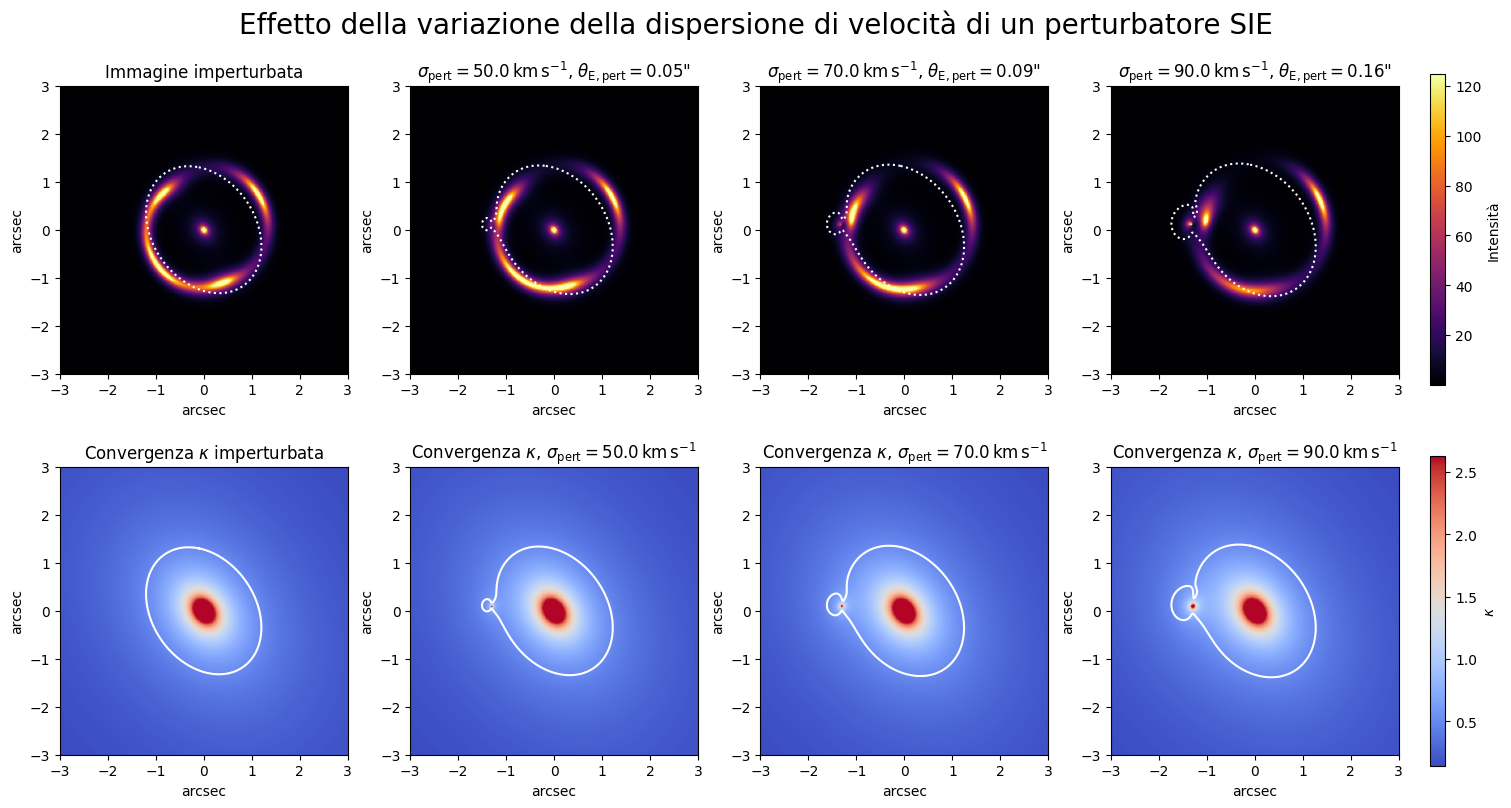

In [14]:
fig3, ax3 = plt.subplots(2, 4, figsize=(15, 8), constrained_layout=True)
fig3.suptitle("Effetto della variazione della dispersione di velocità di un perturbatore SIE", fontsize=20)

vmax_image3 = max(
np.percentile(img[np.isfinite(img)], 99.5)
for img in composite_total_images_all
)

vmax_kappa3 = max(
np.percentile(k[np.isfinite(k)], 99.5)
for k in composite_kappa_maps_all
)

for i, sigma0_pert in enumerate(sigma0_values_pert):

    ax3[0,0].imshow(total_image3, origin="lower", extent=extent, cmap="inferno", vmax=vmax_image3)
    ax3[0,0].set_xlabel("arcsec")
    ax3[0,0].set_ylabel("arcsec")
    
    im0 = ax3[0,i+1].imshow(composite_total_images_all[i], origin="lower", extent=extent, cmap="inferno", vmax=vmax_image3)
    ax3[0,i+1].set_xlabel("arcsec")
    ax3[0,i+1].set_ylabel("arcsec")

    ax3[1,0].imshow(lens3.ka, origin="lower", extent=extent, cmap="coolwarm", vmax=vmax_kappa3)
    ax3[1,0].set_xlabel("arcsec")
    ax3[1,0].set_ylabel("arcsec")

    im1 = ax3[1,i+1].imshow(composite_kappa_maps_all[i], origin="lower", extent=extent, cmap="coolwarm", vmax=vmax_kappa3)
    ax3[1,i+1].set_xlabel("arcsec")
    ax3[1,i+1].set_ylabel("arcsec")

    ax3[0,0].set_title("Immagine imperturbata")
    ax3[1,0].set_title('Convergenza $\kappa$ imperturbata')
    ax3[0,i+1].set_title(
    rf'$\sigma_\mathrm{{pert}}={sigma0_pert}\,\mathrm{{km\,s^{{-1}}}}$, '
    rf'$\theta_\mathrm{{E, pert}}={second_lens_all[i].bsie():.2f}$"')
    ax3[1,i+1].set_title(
    rf'Convergenza $\kappa$, $\sigma_\mathrm{{pert}}={sigma0_pert}\,\mathrm{{km\,s^{{-1}}}}$')

    # ax3[0,3].plot(
    #     pert_pos[0],
    #     pert_pos[1],
    #     marker='+',
    #     color='white',
    #     markersize=6)
    
for i in range(len(sigma0_values_pert)):
    for xcrit, ycrit in composite_critical_lines[i]:
        ax3[0,i+1].plot(xcrit, ycrit, color="white", linestyle="dotted")
        ax3[1,i+1].plot(xcrit, ycrit, color="white")

for xcritu, ycritu in critical_lines3:
    ax3[0,0].plot(xcritu, ycritu, color="white", linestyle="dotted")
    ax3[1,0].plot(xcritu, ycritu, color="white")

for ax in ax3.flat:
    ax.set_aspect("equal")

cbar0 = fig3.colorbar(
    im0,
    ax=ax3[0, :],
    shrink=0.85,
    pad=0.02
)
cbar0.set_label("Intensità")

cbar1 = fig3.colorbar(
    im1,
    ax=ax3[1, :],
    shrink=0.85,
    pad=0.02
)
cbar1.set_label(r"$\kappa$")


## Quanto piccolo può essere un perturbatore e continuare a lasciare una firma gravitazionale misurabile nel modello?

In [15]:
second_lens_kind2 = "SIE" 
second_lens_enabled2 = True

sigma0_values_pert2 = [0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0]
second_lens_all2 = []
composite_lens_all2 = []
composite_critical_lines2 = []

for sigma0_pert2 in sigma0_values_pert2:
    second_sie_kwargs2 = {
    "sigma0": sigma0_pert2, # cambiando qui diminuire, max 90
    "q": 0.9,
    "pa": np.deg2rad(-20.0),
    "theta_c": 1.0e-4,
    "x1": pert_pos[0], # 0.8, 1
    "x2": pert_pos[1], # 1, -1
}

    def build_second_lens2(kind, enabled=True):
        if not enabled:
         return None

        kind = kind.upper()
        if kind == "SIE":
         return sie(co, zl=zl, zs=zs, **second_sie_kwargs2)
        if kind == "NFW":
         return nfwell(co, zl=zl, zs=zs, **second_nfw_kwargs)

        raise ValueError('second_lens_kind must be either "SIE" or "NFW"')

    second_lens2 = build_second_lens2(second_lens_kind2, second_lens_enabled)
    second_lens_all2.append(second_lens2)

    if second_lens2 is None:
        lens_with_second2 = lens3
        critical_lines_with_second2 = critical_lines3
        print("Second mass component disabled; using the original SIE lens.")
    else:
      second_lens2.setGrid(theta=theta)
      lens_with_second2 = compositeModel(co, models=[lens3, second_lens2])
      lens_with_second2.zl = zl
      lens_with_second2.zs = zs
      lens_with_second2.dl = lens3.dl
      lens_with_second2.ds = lens3.ds
      lens_with_second2.dls = lens3.dls
      lens_with_second2.setGrid(theta=theta)
      critical_lines_with_second2 = [lens_with_second2.getCritPoints(cl) for cl in lens_with_second2.tancl()]

      composite_lens_all2.append(lens_with_second2)
      composite_critical_lines2.append(critical_lines_with_second2)

for pert2 in second_lens_all2:
    print(f"Added second {second_lens_kind2.upper()} mass component at "f"({pert2.x1:.2f}, {pert2.x2:.2f}) arcsec")
    print(f"Second SIE Einstein radius: {pert2.bsie():.3f} arcsec")

composite_sources_all2 = []
composite_total_images_all2 = []
composite_kappa_maps_all2 = []
D_all = []
einstein_radii_pert = []

for i, pert2 in enumerate(second_lens_all2):
    source_with_second2 = sersic(
    size=fov,
    Npix=npix,
    gl=composite_lens_all2[i],
    save_unlensed=True,
    **source_kwargs3,
    )
    composite_sources_all2.append(source_with_second2)
    composite_kappa_maps_all2.append(composite_lens_all2[i].ka)
    einstein_radii_pert.append(pert2.bsie())

    total_image_with_second2 = source_with_second2.image + lens_light3.image
    composite_total_images_all2.append(total_image_with_second2)

    print(f"Composite-lens source flux sum: {source_with_second2.image.sum():.3e}")
    print(f"Change relative to original lens: "
      f"{source_with_second2.image.sum() - source3.image.sum():.3e}")

    difference2 = (source_with_second2.image -source3.image)
    D = (np.sqrt(np.sum(difference2**2)))/(np.sqrt(np.sum(source3.image**2)))
    D_all.append(D)
    print(f"D_{i}=", {D})


Added second SIE mass component at (-1.30, 0.10) arcsec
Second SIE Einstein radius: 0.000 arcsec
Added second SIE mass component at (-1.30, 0.10) arcsec
Second SIE Einstein radius: 0.002 arcsec
Added second SIE mass component at (-1.30, 0.10) arcsec
Second SIE Einstein radius: 0.008 arcsec
Added second SIE mass component at (-1.30, 0.10) arcsec
Second SIE Einstein radius: 0.017 arcsec
Added second SIE mass component at (-1.30, 0.10) arcsec
Second SIE Einstein radius: 0.031 arcsec
Added second SIE mass component at (-1.30, 0.10) arcsec
Second SIE Einstein radius: 0.048 arcsec
Added second SIE mass component at (-1.30, 0.10) arcsec
Second SIE Einstein radius: 0.070 arcsec
Added second SIE mass component at (-1.30, 0.10) arcsec
Second SIE Einstein radius: 0.095 arcsec
Added second SIE mass component at (-1.30, 0.10) arcsec
Second SIE Einstein radius: 0.124 arcsec
Added second SIE mass component at (-1.30, 0.10) arcsec
Second SIE Einstein radius: 0.156 arcsec
Composite-lens source flux sum

## Graph


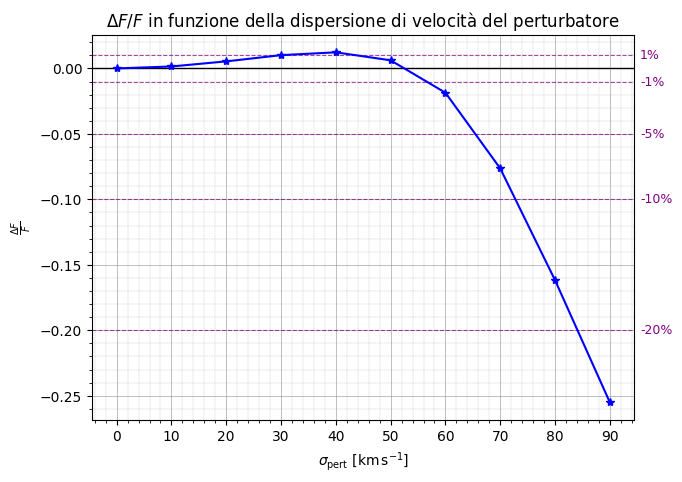

In [24]:
flux_ratio_all = []
for sws in composite_sources_all2:
    flux_ratio = (
    sws.image.sum()
    - source3.image.sum()
 ) / source3.image.sum()
    flux_ratio_all.append(flux_ratio)

fig4, ax4 = plt.subplots(figsize=(7, 5))

percent_levels = [1, 5, 10, 20]  # percentuali da evidenziare


ax4.axhline(
        0.01,
        color="purple",
        linestyle="--",
        linewidth=0.8,
        alpha=0.7
    )
ax4.text(
        1.01,
        0.01,
        "1%",
        transform=ax4.get_yaxis_transform(),
        va="center",
        fontsize=9,
        color="purple"
    )
for p in percent_levels:

    level = p / 100

# livello negativo
    ax4.axhline(
        -level,
        color="purple",
        linestyle="--",
        linewidth=0.8,
        alpha=0.7
    )
# etichette 
    ax4.text(
        1.01,
        -level,
        f"-{p}%",
        transform=ax4.get_yaxis_transform(),
        va="center",
        fontsize=9,
        color="purple"
    )


# Linea dello zero
ax4.axhline(
    0,
    color="black",
    linestyle="-",
    linewidth=1
)


ax4.plot(sigma0_values_pert2, flux_ratio_all, marker='*', color="blue")
ax4.set_xlabel(r'$\sigma_{\mathrm{pert}}\ [\mathrm{km\,s^{-1}}]$')
ax4.set_ylabel(r'$\frac{\Delta F}{F}$')
ax4.set_title(r"$\Delta F/F$ in funzione della dispersione di velocità del perturbatore")
ax4.minorticks_on()
ax4.grid(True, which='major', linestyle="-", linewidth=0.5,
        color="gray", alpha=0.7)
ax4.grid(True, which='minor', linestyle="--", linewidth=0.3,
        color="gray", alpha=0.5)
from matplotlib.ticker import MultipleLocator
ax4.xaxis.set_major_locator(MultipleLocator(10))

plt.show()

## Salvataggio

In [25]:
figure_path3 = outdir / "final_simulations_SIE.png"
fig3.savefig(figure_path3, dpi=180)
print(f"Saved {figure_path3}")

figure_path4 = outdir / "final_simulations_SIE_graph.png"
fig4.savefig(figure_path4, dpi=180)
print(f"Saved {figure_path4}")

Saved /home/sabrina-n/tesi-triennale/outputs/final_simulations_SIE.png
Saved /home/sabrina-n/tesi-triennale/outputs/final_simulations_SIE_graph.png
